# Masterclass: Credit Risk Architecture

Replacing a legacy credit policy with a new score architecture — end to end.

This is the full walkthrough of the library: from the incumbent book to a deployable
policy file. The arc is a real credit-strategy project: measure the current book, pick
the challenger score, price the bureau shields, sweep the efficient frontier, put three
propositions in front of the committee, regionalize the cutoffs, segment risk into
ratings, stress the swap-ins, dissect who moves, read the P&L, crash-test the whole
thing and ship it.

One production fact shapes everything: **`actual_default` is only observed for
applicants who contracted.** A book running under a legacy policy has already rejected
people, and you never saw how the rejects would have repaid. Every step below works
with that constraint, the same one your real book has.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pycreditools import (
    LEGACY_APPROVAL_QUANTILE,
    CreditPolicy,
    CustomStress,
    DeploymentPolicy,
    ModelEvaluator,
    TradeoffAnalyzer,
    col,
    fit_risk_groups,
    generate_sample_data,
    optimize_cutoffs,
    print_delta_table,
    print_quadrant_summary,
    print_rating_quadrant_table,
    print_swap_in_by_rating,
    register_callable,
)
from pycreditools.visualization import plot_crash_test, plot_tradeoffs, plot_vintage_stability

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

## 1. The book and the current panorama

`generate_sample_data` returns an incumbent book: a legacy policy in force, cutting
`legacy_score` at its 78th percentile after a set of bureau knock-outs. Because the
policy is real, the outcome mask is real too — `actual_default` is `NaN` for everyone
who did not contract. The observed P&L of the book lives on the contracted population.

In [2]:
df = generate_sample_data(n_applicants=100_000, seed=42)
LEGACY_CUT = float(df["legacy_score"].quantile(LEGACY_APPROVAL_QUANTILE))

df_hist = df[df["hired"] == 1].copy()   # contracted book: the only place default is observed
df_dev = df[df["sample"] == "DEV"].copy()

N = len(df)
n_aprov = int(df["approved"].sum())
n_hired = int(df["hired"].sum())
bad_hired = df_hist["actual_default"].mean()

print("=== CURRENT PANORAMA (LEGACY POLICY) ===")
print(f"Top of Funnel:                  {N:>10,}")
print(f"Approved (legacy p78):          {n_aprov:>10,}  ({n_aprov / N:.1%} of funnel)")
print(f"Contracted (after take-up):     {n_hired:>10,}  ({n_hired / n_aprov:.1%} of approved)")
print(f"Contracted bad rate (P&L):      {bad_hired:>10.2%}   <- BENCHMARK")
print(f"Legacy score cutoff (p78):      {LEGACY_CUT:>10,.0f}")
print(f"Outcome masked (no contract):   {df['actual_default'].isna().mean():>10.1%}")

=== CURRENT PANORAMA (LEGACY POLICY) ===
Top of Funnel:                     100,000
Approved (legacy p78):              20,431  (20.4% of funnel)
Contracted (after take-up):          9,415  (46.1% of approved)
Contracted bad rate (P&L):           7.56%   <- BENCHMARK
Legacy score cutoff (p78):             789
Outcome masked (no contract):        90.6%


## 2. Predictive power: KS on the contracted book

Which score separates risk best? `ModelEvaluator` computes KS **inside the contracted
book** — the only population where the outcome is observed. The candidate scores
(`score_2` … `score_5`) compete against the incumbent's own `legacy_score`.

In [3]:
all_scores = [f"score_{i}" for i in range(2, 6)] + ["legacy_score"]
ev = ModelEvaluator(df_hist, all_scores, "actual_default")
ks = ev.compute_ks()

ks_df = (
    pd.DataFrame(list(ks.items()), columns=["Model", "KS"])
    .sort_values("KS", ascending=False)
    .reset_index(drop=True)
)
ks_df["KS (%)"] = ks_df["KS"].apply(lambda x: f"{x * 100:.1f}")
ks_df["Power"] = ks_df["KS"].apply(
    lambda x: "Weak" if x < 0.20 else ("Fair" if x < 0.30 else ("Good" if x < 0.45 else "Excellent"))
)
print("=== PREDICTIVE POWER (KS ON THE CONTRACTED BOOK) ===")
print(ks_df[["Model", "KS (%)", "Power"]].to_string(index=False))

print("\n=== DECILE TABLE, CHAMPION SCORE (SCORE 5) ===")
t = ev.compute_ks_table("score_5", bins=10)
print(t.map(lambda x: f"{x:.3f}" if isinstance(x, float) else x).to_string(index=False))

=== PREDICTIVE POWER (KS ON THE CONTRACTED BOOK) ===
       Model KS (%) Power
     score_5   30.9  Good
     score_4   29.9  Fair
     score_3   28.3  Fair
     score_2   28.3  Fair
legacy_score   23.6  Fair

=== DECILE TABLE, CHAMPION SCORE (SCORE 5) ===
 Bucket Avg_Score  Volume Bad_Rate Cum_Bads Cum_Goods    KS
      1   978.670     937    0.009    0.011     0.107 0.096
      2   953.953     935    0.021    0.039     0.212 0.173
      3   931.363     953    0.033    0.083     0.318 0.235
      4   907.506     911    0.048    0.145     0.417 0.273
      5   886.205     935    0.053    0.215     0.519 0.304
      6   862.883     969    0.091    0.338     0.620 0.282
      7   833.899     934    0.088    0.454     0.718 0.265
      8   799.108     958    0.095    0.581     0.818 0.236
      9   751.162     938    0.124    0.744     0.912 0.168
     10   640.506     945    0.193    1.000     1.000 0.000


## 3. Bureau shields and the quality funnel

The hard filters — the bureau knock-outs every applicant must clear before any score
is consulted. The policy below stacks them, then adds the incumbent's own score gate,
so we can read the cost of every stage of the current funnel.

In [4]:
score_cols = [f"score_{i}" for i in range(2, 6)]
base_policy = CreditPolicy(
    applicant_id_col="applicant_id",
    score_cols=score_cols,
    current_approval_col="approved",
    actual_default_col="actual_default",
    time_col="safra",
    calibration_bins=5,
)

policy_hf = (
    base_policy
    .filter("Valid CPF", col("cpf_valido") == True)
    .filter("Negativation ceiling", col("vl_negativacao") <= 1500)
    .filter("SCR arrears ceiling", col("vl_vencido_scr") <= 3000)
    .filter("Protest ceiling", col("vl_protestos") <= 500)
)

policy_legacy_hf = policy_hf.filter("Incumbent score gate", col("legacy_score") >= LEGACY_CUT)

sim_funnel = policy_legacy_hf.simulate(df_dev, method="analytical")
stages = [
    ("Top of Funnel", pd.Series(True, index=df_dev.index)),
    ("Valid CPF", df_dev["cpf_valido"] == True),
    ("Negativation ceiling", df_dev["vl_negativacao"] <= 1500),
    ("SCR arrears ceiling", df_dev["vl_vencido_scr"] <= 3000),
    ("Protest ceiling", df_dev["vl_protestos"] <= 500),
    ("Incumbent score gate", df_dev["legacy_score"] >= LEGACY_CUT),
]
print("=== APPROVAL FUNNEL (DEV BASE) ===")
print(f"{'Stage':<26} {'Volume':>10}  {'% Funnel':>9}  {'Step':>8}")
print("-" * 60)
running = pd.Series(True, index=df_dev.index)
prev_n = len(df_dev)
for name, mask in stages:
    running = running & mask
    n = int(running.sum())
    delta = f"{(n - prev_n) / prev_n:+.1%}" if name != "Top of Funnel" else "-"
    print(f"{name:<26} {n:>10,}  {n / len(df_dev):>9.1%}  {delta:>8}")
    prev_n = n

# Survivor frame of the *new* hard filters (no legacy gate): the candidate scores
# will be swept on this population. The swap-in reliability warning this simulate
# raises is answered by the standing posture declared in section 4.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sim_hf = policy_hf.simulate(df_dev, method="analytical")
df_clean_hf = sim_hf.data[sim_hf.data["new_approval"] == 1.0].copy()

=== APPROVAL FUNNEL (DEV BASE) ===
Stage                          Volume   % Funnel      Step
------------------------------------------------------------
Top of Funnel                  66,601     100.0%         -
Valid CPF                      66,470      99.8%     -0.2%
Negativation ceiling           60,306      90.5%     -9.3%
SCR arrears ceiling            56,225      84.4%     -6.8%
Protest ceiling                52,442      78.7%     -6.7%
Incumbent score gate           13,423      20.2%    -74.4%


## 4. Efficient frontier: every candidate score, stressed

The trade-off curve — approval rate against contracted default rate — for each
candidate score, swept across its cutoff range while the hard filters and the take-up
stage stay fixed.

Two modelling choices, declared once and carried through the whole study:

- **Take-up is an observed outcome, not an assumption.** The `RateStage` calibrates the
  observed `hired` outcome by score decile, so contracted volume responds to where the
  cutoff moves.
- **Swap-ins are priced conservatively.** A challenger cutoff approves applicants the
  incumbent rejected — people who never contracted, whose default was never observed.
  The engine imputes their PD from the score bands of the observed book and warns that
  this is an extrapolation. We answer the warning the conservative way: a flat
  **aggravation stress of 1.2×** on every swap-in PD, the same posture at every point
  of every curve. The stress is a policy decision about prudence, not a fit.

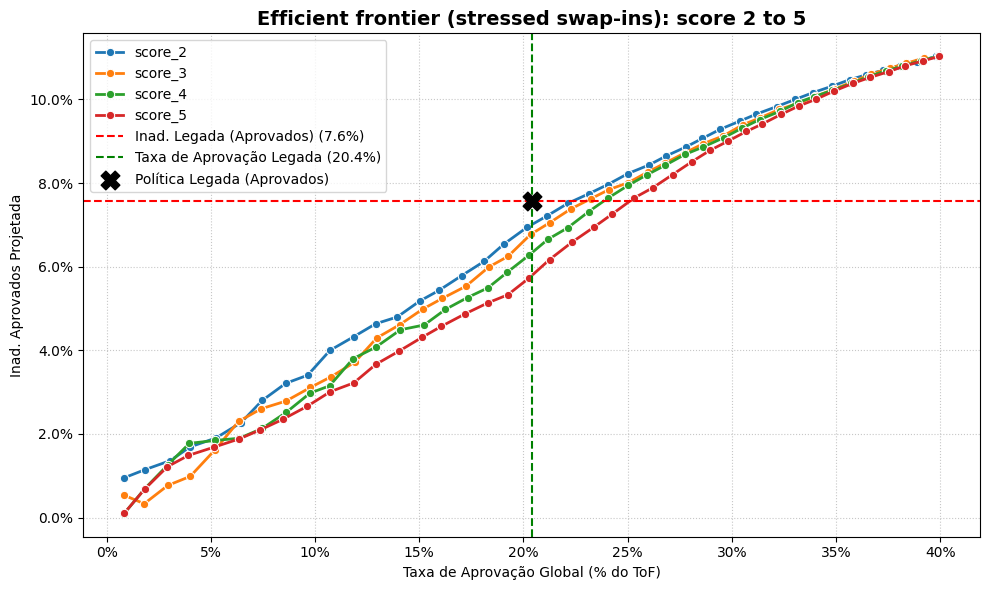

In [5]:
AGGRAVATION_BASE = 1.2

policy_take = policy_hf.rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
policy_tradeoff = policy_take.stress(AGGRAVATION_BASE)

# No operating point above ~40% approval is worth underwriting on this book, so the
# sweep spends its resolution where the decision lives: a dense 45-point grid over the
# upper score range, then everything above the 40% approval ceiling is dropped.
APPROVAL_CEILING = 0.40
cutoffs = np.linspace(
    df_clean_hf["score_5"].quantile(0.35), df_clean_hf["score_5"].quantile(0.99), 55
).astype(int).tolist()

res_list = []
with warnings.catch_warnings():
    # The swap-in reliability warning fires at every grid point; the 1.2x stress and
    # calibration_bins=5 above are this study's standing answer to it.
    warnings.simplefilter("ignore")
    for i in range(2, 6):
        an = TradeoffAnalyzer(policy_tradeoff).vary_cutoff(f"score_{i}", cutoffs, direction="gte")
        r = an.run(df_dev, parallel=False)
        r["Score_Model"] = f"score_{i}"
        r["Cutoff"] = r[f"score_{i}_cutoff"]
        res_list.append(r)
res_all = pd.concat(res_list)
res_all = res_all[res_all["approval_rate"] <= APPROVAL_CEILING].reset_index(drop=True)

plot_tradeoffs(
    res_all,
    legacy_approval_rate=n_aprov / N,
    legacy_bad_rate=bad_hired,
    title="Efficient frontier (stressed swap-ins): score 2 to 5",
    hue_col="Score_Model",
)
plt.show()

## 5. The three executive propositions (score 5)

`score_5` dominates the frontier. The committee does not want a curve — it wants
operating points. Three risk appetites, all read off the same swept grid:

1. **Conservative** — hold the legacy approval rate, collect the default improvement.
2. **Aggressive** — hold the legacy default rate, collect the approval expansion.
3. **Neutral** — the midpoint cutoff between the two.

=== THE THREE EXECUTIVE PROPOSITIONS ===
Scenario                 Cutoff  Approval (ToF)  Contracted bad
----------------------------------------------------------------
1. Conservative             790          20.27%           5.73%
2. Aggressive               737          25.31%           7.64%
3. Neutral                  769          22.32%           6.58%
----------------------------------------------------------------
Legacy (reference)            -          20.43%           7.56%


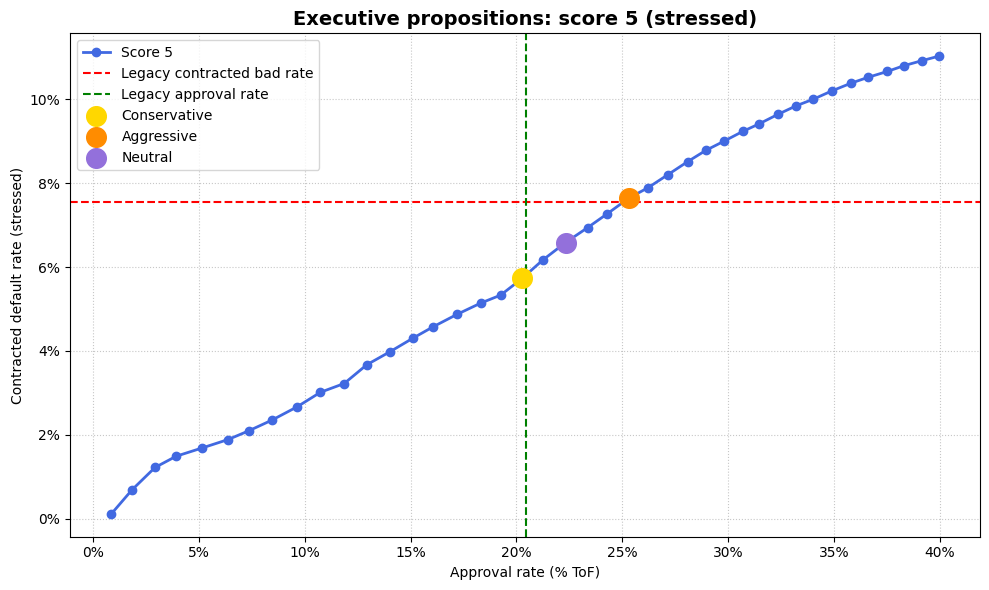


Committee decision: the NEUTRAL proposition -> national cutoff score_5 >= 769
Approval budget to preserve: 22.32% of ToF


In [6]:
res_s5 = res_all[res_all["Score_Model"] == "score_5"].copy()

pol_cons = res_s5.iloc[(res_s5["approval_rate"] - n_aprov / N).abs().argsort()[:1]]
pol_agr = res_s5.iloc[(res_s5["default_rate"] - bad_hired).abs().argsort()[:1]]
mid_cut = (pol_cons["Cutoff"].iloc[0] + pol_agr["Cutoff"].iloc[0]) / 2
pol_mid = res_s5.iloc[(res_s5["Cutoff"] - mid_cut).abs().argsort()[:1]]

print("=== THE THREE EXECUTIVE PROPOSITIONS ===")
print(f"{'Scenario':<22} {'Cutoff':>8} {'Approval (ToF)':>15} {'Contracted bad':>15}")
print("-" * 64)
for label, pol in [("1. Conservative", pol_cons), ("2. Aggressive", pol_agr), ("3. Neutral", pol_mid)]:
    print(
        f"{label:<22} {int(pol['Cutoff'].iloc[0]):>8} "
        f"{pol['approval_rate'].iloc[0]:>15.2%} {pol['default_rate'].iloc[0]:>15.2%}"
    )
print("-" * 64)
print(f"{'Legacy (reference)':<22} {'-':>8} {n_aprov / N:>15.2%} {bad_hired:>15.2%}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(res_s5["approval_rate"], res_s5["default_rate"], marker="o", lw=2, color="royalblue", label="Score 5")
ax.axhline(bad_hired, color="r", ls="--", lw=1.5, label="Legacy contracted bad rate")
ax.axvline(n_aprov / N, color="g", ls="--", lw=1.5, label="Legacy approval rate")
for label, pol, c in [("Conservative", pol_cons, "gold"), ("Aggressive", pol_agr, "darkorange"), ("Neutral", pol_mid, "mediumpurple")]:
    ax.scatter(pol["approval_rate"], pol["default_rate"], color=c, s=200, zorder=6, label=label)
ax.set_title("Executive propositions: score 5 (stressed)", fontsize=14, fontweight="bold")
ax.set_xlabel("Approval rate (% ToF)")
ax.set_ylabel("Contracted default rate (stressed)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.grid(True, ls=":", alpha=0.7)
ax.legend()
fig.tight_layout()
plt.show()

neutral_cut = int(pol_mid["Cutoff"].iloc[0])
target_approval = float(pol_mid["approval_rate"].iloc[0])
print(f"\nCommittee decision: the NEUTRAL proposition -> national cutoff score_5 >= {neutral_cut}")
print(f"Approval budget to preserve: {target_approval:.2%} of ToF")

### The simplified policy — one national cutoff

The committee's choice, materialised as a real policy: the hard filters, a single
national `score_5` cutoff at the Neutral operating point, take-up and the 1.2× swap-in
stress. This is the **simplified** policy — one rule for the whole country. It is the
second of the three books this notebook compares (the incumbent is the first).

In [7]:
policy_simplified = (
    policy_hf
    .cutoff("National score cutoff", {"score_5": neutral_cut}, direction="gte")
    .rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
    .stress(AGGRAVATION_BASE)
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sim_simplified = policy_simplified.simulate(df, method="analytical")

for name, fn in [
    ("approval_rate", lambda d: (d["approved_pre_rate"] > 0).sum() / len(d)),
    ("contracted", lambda d: d["new_approval"].sum()),
    ("default_rate", lambda d: (d["simulated_default"] * d["new_approval"]).sum() / d["new_approval"].sum()),
]:
    print(f"{name:>14}: {fn(sim_simplified.data):.4f}")

 approval_rate: 0.2208
    contracted: 10051.0408
  default_rate: 0.0615


## 5b. Sanity check: the champion score, decile by decile

Before regionalising anything, look at what the simplified policy actually did, laid
out by `score_5` decile over its approved population. Each applicant it approves is
either a **keep-in** (the incumbent approved them too — outcome observed) or a
**swap-in** (the incumbent rejected them — no outcome ever observed). Split each by
whether they end up contracting, and read volume and default side by side.

Two facts should jump out and confirm the whole setup:

- swap-ins pile into the **low** deciles (they scored below the incumbent's gate) and
  keep-ins into the **high** ones;
- the *não-contratado* columns carry no default — you cannot observe repayment on a
  loan that was never taken — which is exactly the mask everything here works around.
The contracted default for swap-ins is the 1.2×-stressed imputation, not an observed
number.

In [8]:
appr = sim_simplified.data[sim_simplified.data["scenario"].isin(["keep_in", "swap_in"])].copy()
appr["decile"] = pd.qcut(appr["score_5"], 10, labels=False, duplicates="drop") + 1


def _bad(x):
    w = x["new_approval"]
    return (x["simulated_default"] * w).sum() / w.sum() if w.sum() else np.nan


def _bucket(g):
    ki, si = g[g["scenario"] == "keep_in"], g[g["scenario"] == "swap_in"]
    return pd.Series(
        {
            "KI_contr_vol": ki["new_approval"].sum(),
            "KI_contr_bad": _bad(ki),
            "KI_notcontr_vol": (ki["approved_pre_rate"] - ki["new_approval"]).sum(),
            "SI_contr_vol": si["new_approval"].sum(),
            "SI_contr_bad": _bad(si),
            "SI_notcontr_vol": (si["approved_pre_rate"] - si["new_approval"]).sum(),
        }
    )


tab = appr.groupby("decile").apply(_bucket, include_groups=False)
fmt = tab.copy()
for c in ["KI_contr_vol", "KI_notcontr_vol", "SI_contr_vol", "SI_notcontr_vol"]:
    fmt[c] = tab[c].round().astype(int).map(lambda v: f"{v:,}")
for c in ["KI_contr_bad", "SI_contr_bad"]:
    fmt[c] = tab[c].map(lambda v: f"{v:.1%}" if pd.notna(v) else "-")
fmt.columns = pd.MultiIndex.from_tuples(
    [
        ("keep_in", "contr. vol"), ("keep_in", "contr. bad"), ("keep_in", "not-contr. vol"),
        ("swap_in", "contr. vol"), ("swap_in", "contr. bad"), ("swap_in", "not-contr. vol"),
    ]
)
print("=== SCORE_5 DECILE SANITY CHECK (simplified policy, approved population) ===")
print(fmt.to_string())

=== SCORE_5 DECILE SANITY CHECK (simplified policy, approved population) ===


          keep_in                              swap_in                          
       contr. vol contr. bad not-contr. vol contr. vol contr. bad not-contr. vol
decile                                                                          
1             475       8.2%            405        753      10.5%            631
2             537       8.9%            522        580      10.5%            599
3             569       9.0%            665        452      10.5%            481
4             689       7.4%            754        392       8.4%            417
5             794       6.9%            883        250       8.2%            288
6             816       4.8%            971        181       5.9%            209
7             797       4.1%          1,193        109       5.2%            153
8             817       2.4%          1,207         67       3.0%             99
9             833       2.2%          1,194         41       2.1%             59
10            856       0.5

## 6. Reallocating the mix per region — same budget, better default

One national cutoff spends the approval budget blind to geography: the same threshold
over-lends where risk runs high and under-lends where it runs low. Hold the committee's
**aggregate approval budget fixed** — the same  of ToF the simplified policy
approves — but **move the mix**: approve a little more in the low-risk regions and a
little less in the high-risk ones. Same total volume, a lower blended default.

The mechanism is a single common stressed-default target τ applied per region: raise τ
and every region loosens together, lifting aggregate approval; lower it and they
tighten. Searching τ until the regional book reproduces the simplified policy's
aggregate approval finds the reallocation that holds the budget and banks the mix
improvement. The per-region search is `optimize_cutoffs`, declared-direction, under the
same hard filters, take-up stage and 1.2× swap-in stress.

In [9]:
# One score dial per region: the config declares score_5 as its only score, so the
# optimizer returns a single cutoff per slice rather than a joint combination.
config = (
    CreditPolicy(
        applicant_id_col="applicant_id",
        score_cols=("score_5",),
        current_approval_col="approved",
        actual_default_col="actual_default",
        time_col="safra",
        calibration_bins=5,
    )
    .filter("Valid CPF", col("cpf_valido") == True)
    .filter("Negativation ceiling", col("vl_negativacao") <= 1500)
    .filter("SCR arrears ceiling", col("vl_vencido_scr") <= 3000)
    .filter("Protest ceiling", col("vl_protestos") <= 500)
    .rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
    .stress(AGGRAVATION_BASE)
)


def regional_cutoffs_for(tau):
    cuts, weighted_appr = {}, 0.0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for region, sub in df_dev.groupby("region"):
            o = optimize_cutoffs(
                sub, config, cutoff_steps=25, target_default_rate=tau,
                min_approval_rate=0.01, directions={"score_5": "gte"},
            )
            cuts[region] = int(round(o.best_combination["score_5"]))
            weighted_appr += o.metrics["overall_approval_rate"] * len(sub)
    return cuts, weighted_appr / len(df_dev)


# Bisect the common default target until aggregate approval matches the budget.
lo, hi = 0.03, 0.15
for _ in range(12):
    mid = (lo + hi) / 2
    _, agg = regional_cutoffs_for(mid)
    if agg < target_approval:
        lo = mid
    else:
        hi = mid
tau_star = (lo + hi) / 2
cutoffs_by_region, agg_approval = regional_cutoffs_for(tau_star)

print(f"Common stressed-default target found: tau = {tau_star:.2%}")
print(f"Aggregate approval: {agg_approval:.2%}  (budget: {target_approval:.2%})\n")

rows = []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for region, sub in df_dev.groupby("region"):
        cut = cutoffs_by_region[region]
        s = config.cutoff("c", {"score_5": cut}, direction="gte").simulate(sub, method="analytical").data
        appr_r = (s["approved_pre_rate"] > 0).sum() / len(sub)
        dflt_r = (s["simulated_default"] * s["new_approval"]).sum() / s["new_approval"].sum()
        rows.append({"region": region, "applicants": len(sub), "cutoff": cut,
                     "approval_rate": round(appr_r, 4), "stressed_default": round(dflt_r, 4)})
print("=== PER-REGION CUTOFFS (MIX REALLOCATED AT FIXED AGGREGATE APPROVAL) ===")
print(pd.DataFrame(rows).sort_values("cutoff").to_string(index=False))


def regional_score_gate(df_in):
    passes = pd.Series(False, index=df_in.index)
    for region, cut in cutoffs_by_region.items():
        passes.loc[(df_in["region"] == region) & (df_in["score_5"] >= cut)] = True
    return passes


register_callable("regional_score_gate", regional_score_gate)

policy_final = (
    policy_hf
    .filter("Regional score cutoffs", regional_score_gate)
    .rate("Take-up", base_rate=1.0, observed_col="hired", calibrate_by="score")
)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sim_final = policy_final.simulate(df, method="analytical")
res_final = sim_final.data

Common stressed-default target found: tau = 7.28%
Aggregate approval: 22.23%  (budget: 22.32%)



=== PER-REGION CUTOFFS (MIX REALLOCATED AT FIXED AGGREGATE APPROVAL) ===
      region  applicants  cutoff  approval_rate  stressed_default
       Norte        4619     748         0.2178            0.0590
    Nordeste       11849     750         0.2196            0.0583
     Sudeste       30055     760         0.2386            0.0606
Centro-Oeste        6685     796         0.1943            0.0565
         Sul       13393     797         0.2072            0.0651


### The three books, side by side

The whole point of holding the budget fixed: at the **same** aggregate approval, the
regional reallocation should carry a **lower** blended default than the single national
cutoff. `print_delta_table` reads all three books off their simulations — the incumbent
as the reference, then *New 1 = simplified* (one national cutoff) and *New 2 = regional*
(the reallocated mix). Both swap-in bad rates rest on the 1.2× stress.

In [10]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print_delta_table([sim_simplified, sim_final])

=== DELTA TABLE: EXECUTIVE P&L ===
Metric                                      Legacy         New 1         New 2
------------------------------------------------------------------------------
Global Approval Rate (% ToF)                20.43%        22.09%        22.11%
  Delta Abs (vs Legacy)                                   +1.65%        +1.68%
  Delta Rel (vs Legacy)                                    +8.1%         +8.2%
Expected Bad Rate                            7.56%         6.15%         5.72%
  Delta Abs (vs Legacy)                                   -1.42%        -1.84%
  Delta Rel (vs Legacy)                                   -18.7%        -24.3%


## 7. Risk segmentation: ratings fit on the surviving book, validated out of time

A cutoff is a yes/no; a **rating** is the price. `fit_risk_groups` clusters the
approved survivors into risk grades — fit strictly where the outcome is observed (the
contracted survivors) and split by vintage: grades are learned on the 2024 vintages
and the report shows how each grade's default holds up on the held-out 2025 ones. A
grade ladder that survives out of time is a grade ladder you can price with.

grades: 3

=== RATING VALIDATION: TRAIN vs OOT ===
period  Train    OOT
grade               
A       0.018  0.014
B       0.045  0.042
C       0.080  0.088


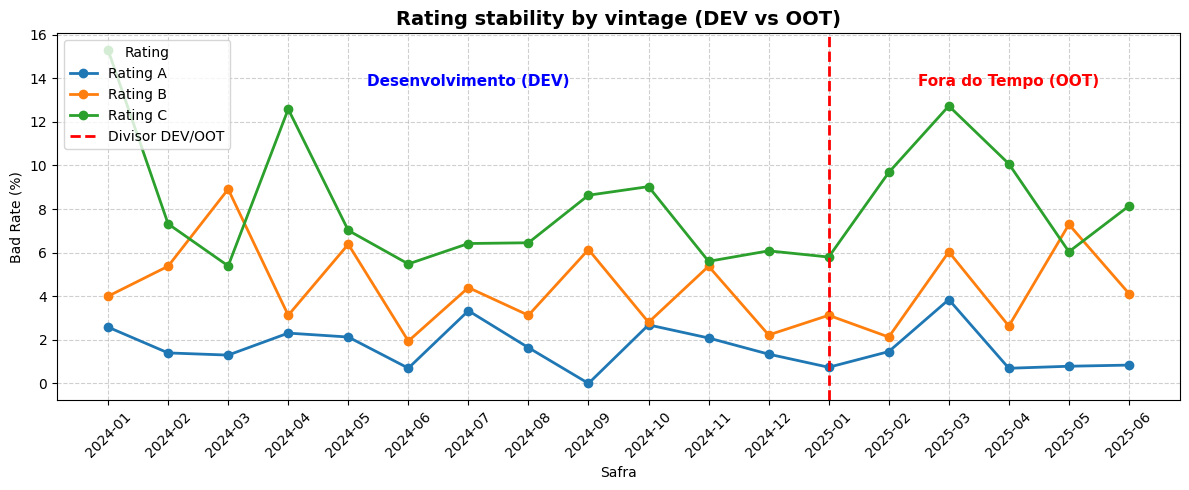

In [11]:
train = res_final[(res_final["new_approval"] > 0.0) & (res_final["hired"] == 1)].copy()

rating = fit_risk_groups(
    train,
    "score_5",
    "actual_default",
    bins=20,
    max_groups=5,
    min_vol_ratio=0.05,
    max_crossings=3,
    time_col="safra",
    oot_date="2025-01",
)
LETTERS = {1: "A", 2: "B", 3: "C", 4: "D", 5: "E"}

report = rating.report.copy()
report["grade"] = report["risk_rating"].map(LETTERS)
report["pd"] = report["pd"].round(3)
print(f"grades: {rating.n_groups}")
print("\n=== RATING VALIDATION: TRAIN vs OOT ===")
print(report.pivot(index="grade", columns="period", values="pd")[["Train", "OOT"]].to_string())

recipe = rating.recipe
df["Rating"] = recipe.predict(df)["risk_rating"].map(LETTERS)
res_final["Rating"] = recipe.predict(res_final)["risk_rating"].map(LETTERS)

plot_vintage_stability(
    res_final[res_final["hired"] == 1],
    rating_col="Rating",
    time_col="safra",
    default_col="actual_default",
    approval_col="new_approval",
    oot_start_safra="2025-01",
    title="Rating stability by vintage (DEV vs OOT)",
)
plt.show()

## 8. The final policy under rating-angled stress

The flat 1.2× swap-in stress served the sweeps; the shipped simulation can be sharper.
A swap-in landing in grade A is a smaller leap of faith than one landing in grade E,
so the aggravation is **angled by rating** — anchored at the same 1.2× base, rising
toward the riskier grades. Still a declared prudence posture; now a graduated one.

In [12]:
def angled_by_rating(df_swap, pd_col):
    factor_map = {
        "A": AGGRAVATION_BASE,
        "B": AGGRAVATION_BASE + 0.1,
        "C": AGGRAVATION_BASE + 0.2,
        "D": AGGRAVATION_BASE + 0.2,
        "E": AGGRAVATION_BASE + 0.3,
    }
    factor = df_swap["Rating"].map(factor_map).fillna(AGGRAVATION_BASE + 0.2)
    return (df_swap[pd_col] * factor).clip(0, 1)


policy_stressed = policy_final.add_stress(CustomStress(angled_by_rating))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sim_stressed = policy_stressed.simulate(df, method="analytical")

new_approval_rate = (sim_stressed.data["approved_pre_rate"] > 0).sum() / N
print(f"New policy approval rate: {new_approval_rate:.2%}  (legacy: {n_aprov / N:.2%})")

New policy approval rate: 22.11%  (legacy: 20.43%)


## 9. Dissecting the swaps: who comes in, who goes out

Every applicant falls in one of four quadrants against the incumbent: kept in, kept
out, swapped in, swapped out. The library prints the dissection directly — volumes,
contracted volumes and the bad rate each quadrant carries, then the swap-ins broken
down by the rating grade they arrive in.

In [13]:
print_quadrant_summary(sim_stressed)

print_swap_in_by_rating(sim_stressed, rating_col="Rating")

print("\n=== SWAP-INS: RATING x REGION (expected contracted volume) ===")
si = sim_stressed.data[sim_stressed.data["scenario"] == "swap_in"]
si_rg = (
    si.groupby(["Rating", "region"])["new_approval"].sum().unstack(fill_value=0).sort_index(ascending=False)
)
print(si_rg.map(lambda x: f"{int(x):,}").to_string())

print_rating_quadrant_table(sim_stressed, rating_col="Rating")

=== QUADRANTES: VOLUME ESPERADO CONTRATADO E INADIMPLÊNCIA ===
Quadrante      Vol. Contratado      Bad Rate  Fonte
─────────────────────────────────────────────────────────────────
Keep In                  7,114         4.96%  actual_default (observado)
Swap In                  2,916        10.54%  simulated_default (agravado/simulado)
Swap Out                 2,301        15.60%  actual_default (observado na carteira antiga)
Keep Out                     0           N/A  sem dados (reprovados por ambas)

=== RAIO-X DOS SWAP INS POR RATING ===
  Rating   Vol. Esperado    Vol %   Inad Stressed
──────────────────────────────────────────────────
       C           2,425    83.2%          11.62%
       B             344    11.8%           6.49%
       A             147     5.0%           2.24%

=== SWAP-INS: RATING x REGION (expected contracted volume) ===
region Centro-Oeste Nordeste Norte Sudeste  Sul
Rating                                         
C               147      510   219   1,2

## 10. Delta table: the executive P&L

One table for the board: against the legacy policy, what the new architecture does to
approval, to expected bad rate and to contracted volume. Swap-in risk in these numbers
carries the rating-angled stress from section 8 — the conservative reading, not the
optimistic one.

In [14]:
print_delta_table(sim_stressed)

=== DELTA TABLE: EXECUTIVE P&L ===
Metric                                  Legacy         New   Delta Abs   Delta Rel
------------------------------------------------------------------------------
Global Approval Rate (% ToF)            20.43%      22.11%      +1.68%       +8.2%
Expected Bad Rate                        7.56%       6.58%      -0.98%      -12.9%
Expected Hired Volume                    9,415      10,030        +615       +6.5%


## 11. Crash test: the swap-in airbag

The one number every risk committee asks for: **how wrong can the swap-in pricing be
before the new policy stops beating the old one?** Sweep the aggravation factor up to
10× and find the breakeven — the factor at which the projected bad rate meets the
legacy benchmark.

BREAKEVEN FOUND: factor = 2.00x
  Projected bad rate: 7.79% (ceiling: 7.56%)
  The swap-ins' real PD would have to be 2.00x worse than priced
  for the new P&L to fall back to the legacy one.


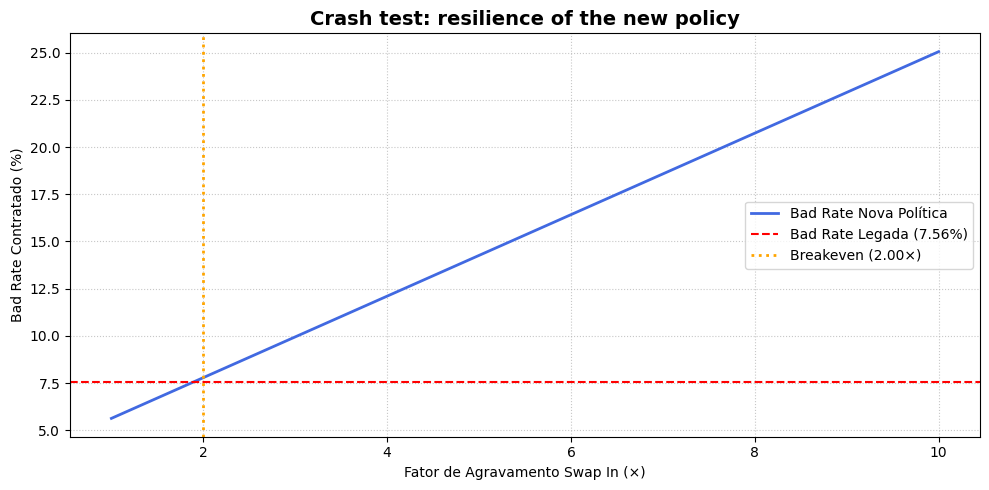

In [15]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    an_st = TradeoffAnalyzer(policy_final).vary_stress_aggravation(np.linspace(1.0, 10.0, 10).tolist())
    res_st = an_st.run(df_dev, parallel=False)

breakeven = None
for _, row in res_st.iterrows():
    if row["default_rate"] >= bad_hired:
        breakeven = row["aggravation_factor"]
        print(f"BREAKEVEN FOUND: factor = {breakeven:.2f}x")
        print(f"  Projected bad rate: {row['default_rate']:.2%} (ceiling: {bad_hired:.2%})")
        print(f"  The swap-ins' real PD would have to be {breakeven:.2f}x worse than priced")
        print(f"  for the new P&L to fall back to the legacy one.")
        break
if breakeven is None:
    print("The new policy does not regress even at a 10x swap-in stress.")

plot_crash_test(
    res_st,
    legacy_bad_rate=bad_hired,
    breakeven_factor=breakeven,
    title="Crash test: resilience of the new policy",
)
plt.show()

## 12. Export: from study to production

The final step freezes the whole decision stack — hard filters, regional cutoffs and
the rating recipe — into a single JSON file. Production loads that file and decides:
every new applicant gets a decision, the first rule that rejected them, and a rating
grade if approved.

In [16]:
dep_policy = policy_final.export(rating_recipe=recipe, path="masterclass_policy.json")
print("Final policy exported to 'masterclass_policy.json'")

dep_loaded = DeploymentPolicy.load("masterclass_policy.json")

sample = df_dev.sample(10, random_state=42).copy()
decisions = dep_loaded.predict(sample, simple=True)

print("\n=== PRODUCTION DECISION BASE (SAMPLE) ===")
cols_show = [
    c
    for c in [
        "applicant_id", "region", "score_5", "age", "vl_negativacao",
        "decision", "reason", "hired", "defaulted", "scenario", "rating",
        "decisao", "motivo", "contratou", "inadimplente", "cenario",
    ]
    if c in decisions.columns
]
print(decisions[cols_show].to_string(index=False))

Final policy exported to 'masterclass_policy.json'

=== PRODUCTION DECISION BASE (SAMPLE) ===
 applicant_id       region  score_5  age  vl_negativacao decision                    reason  hired  defaulted scenario rating
        11111          Sul      174   41               0 Rejected 5: Regional score cutoffs    0.0        NaN Keep Out      C
        68280     Nordeste      107   16               0 Rejected        4: Protest ceiling    0.0        NaN Keep Out      C
        82474      Sudeste      922   42               0 Approved                  Approved    1.0        NaN  Keep In      B
        55443      Sudeste      888   21               0 Approved                  Approved    1.0        NaN  Keep In      B
        77744      Sudeste      818   39               0 Approved                  Approved    1.0        0.0  Swap In      C
        56873      Sudeste      459   44               0 Rejected 5: Regional score cutoffs    0.0        NaN Keep Out      C
        48613          S

## Where this leaves you

Twelve steps, one thread: measure where the outcome is observed, declare every
assumption you cannot measure, and make the machine carry the declared posture
everywhere — through the frontier, the regional cutoffs, the ratings, the P&L and the
crash test. The exported JSON is the whole study, compressed into the only artefact
production needs.